# HCN ⇌ HNC — reactive-MLIP pipeline **validation** (closed-shell, known barrier)

A clean calibration of the whole pipeline on a reaction with **no spin/multireference**
pathology: the H migrates from C to N, closed-shell singlet throughout, so restricted DFT
(RKS) describes it correctly. Literature forward barrier ≈ **125–190 kJ/mol** and HNC sits
≈ **60 kJ/mol** above HCN — so you can *check* your FES against real numbers.

Pipeline unchanged from the CH₄ version: Psi4 label → DeePMD train → OPES along the
`d(C–H) − d(N–H)` CV → reweighted FES → committee/AL. **New:** a reference **NEB** stage
(Stage F) gives an independent 0 K barrier to cross-check OPES against, emulating the RAL paper.

Atom order everywhere: **C, N, H** (PLUMED 1-indexed: C=1, N=2, H=3).

## 1 · Environment
The env is created once in the terminal. This notebook just *uses* it — the kernel **is** the
conda env, so `import psi4, deepmd, ase, plumed` work directly (no `!{PY}` needed for imports).

In [1]:
import sys, os, glob
PY = sys.executable                                  # the kernel IS the conda env
ENV_PREFIX = os.path.dirname(os.path.dirname(PY))    # .../envs/ch4mlip
ker = glob.glob(f'{ENV_PREFIX}/lib/libplumedKernel.so')
if ker: os.environ['PLUMED_KERNEL'] = ker[0]
print('kernel python :', PY)
print('env prefix    :', ENV_PREFIX)
print('PLUMED_KERNEL :', os.environ.get('PLUMED_KERNEL'))

kernel python : /home/hp/miniforge3/envs/ch4mlip/bin/python
env prefix    : /home/hp/miniforge3/envs/ch4mlip
PLUMED_KERNEL : /home/hp/miniforge3/envs/ch4mlip/lib/libplumedKernel.so


## 2 · Verify the env (imports run in-kernel now)

In [2]:
import psi4, deepmd, ase, plumed
print('GATE 0 OK — psi4, deepmd, ase, plumed all import in this kernel')

GATE 0 OK — psi4, deepmd, ase, plumed all import in this kernel


In [3]:
!conda list 2>/dev/null | grep -E '^(psi4|deepmd-kit|plumed|py-plumed|ase) ' || true

ase                              3.29.0           pyhd8ed1ab_1                   conda-forge
deepmd-kit                       3.1.3            cpu_py311h626087f_mpi_mpich_1  conda-forge
plumed                           2.10.0           nompi_h4679bf9_100             conda-forge
psi4                             1.10.2           py311h5e4aff1_1                conda-forge
py-plumed                        2.9.2            py311h9ecbd09_1                conda-forge


## 2.5 · Confirm PLUMED has the OPES module
The opes-enabled PLUMED kernel is built **once in the terminal** (see setup steps). This cell just
confirms it's live in the kernel. If it prints FAILED, run the terminal OPES-build step, then
**restart the kernel** (Kernel ▸ Restart) and re-run — the new kernel `.so` only loads on a fresh kernel.

In [3]:
import plumed
def has_opes():
    try:
        p = plumed.Plumed(); p.cmd('setNatoms', 5); p.cmd('setTimestep', 1.0)
        p.cmd('setKbT', 2.5); p.cmd('setLogFile', '/tmp/o.log'); p.cmd('init')
        p.cmd('readInputLine', 'd: DISTANCE ATOMS=1,2')
        p.cmd('readInputLine', 'o: OPES_METAD ARG=d PACE=500 BARRIER=10')
        return True
    except Exception as e:
        print('OPES probe error:', e); return False
ok = has_opes()
print('GATE OPES', 'OK' if ok else 'FAILED — run the terminal OPES-build step, then restart the kernel')

GATE OPES OK


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/hp/miniforge3/envs/ch4mlip/lib/libplumedKernel.so" +++


# Stage A · Generate HCN⇌HNC geometries + label with Psi4 (**RKS, closed-shell**)

In [4]:
import os
os.environ['CH4_ROOT'] = os.path.expanduser('~/hcn-mlip')   # local persistent disk
os.makedirs(os.environ['CH4_ROOT'], exist_ok=True)
print('persisting to', os.environ['CH4_ROOT'])

persisting to /home/hp/hcn-mlip


In [5]:
%%writefile gen_and_label.py
import numpy as np, os, glob
import psi4

ROOT   = os.environ.get("CH4_ROOT", os.path.expanduser("~/ch4-mlip"))
FRAMES = os.path.join(ROOT, "frames")
DATA   = os.path.join(ROOT, "data")
os.makedirs(FRAMES, exist_ok=True)
os.makedirs(os.path.join(DATA, "set.000"), exist_ok=True)

HART2EV = 27.211386245988
BOHR2A  = 0.529177210903
F_CONV  = HART2EV / BOHR2A

psi4.set_memory('2 GB'); psi4.core.set_num_threads(2)
psi4.set_output_file('psi4_out.log', False)
# CLOSED-SHELL: restricted KS, singlet. No uks/guess_mix -> no symmetry-breaking,
# no S^2 collapse. This is the whole reason HCN<->HNC is a clean validation.
psi4.set_options({'reference':'rks', 'maxiter':250, 'basis':'def2-tzvp', 'scf_type':'df'})

SYM = ['C','N','H']
dCN = 1.16
C0 = np.array([0.,0.,0.]); N0 = np.array([dCN,0.,0.])
H_HCN = C0 + np.array([-1.066, 0., 0.])      # linear H-C-N
H_HNC = N0 + np.array([ 0.994, 0., 0.])      # linear C-N-H

def geom(t, bulge=1.55):
    """H migrates C->N over a bent bridge as t: 0 (HCN) -> 1 (HNC)."""
    H = (1-t)*H_HCN + t*H_HNC + np.array([0., bulge*np.sin(np.pi*t), 0.])
    return np.vstack([C0, N0, H])

def make_mol(pos):
    lines = ["0 1"] + [f"{s} {p[0]:.8f} {p[1]:.8f} {p[2]:.8f}" for s,p in zip(SYM,pos)]
    lines += ["units angstrom","symmetry c1","no_com","no_reorient"]
    return psi4.geometry("\n".join(lines))

def label(pos):
    mol = make_mol(pos)
    try:
        g, wfn = psi4.gradient('b3lyp', molecule=mol, return_wfn=True)
    except Exception as e:
        print("  SCF/gradient failed:", e); return None
    coords = mol.geometry().to_array()*BOHR2A
    return coords, wfn.energy()*HART2EV, -np.array(g)*F_CONV

# ---------- deterministic pool ----------
rng = np.random.default_rng(0)
pool = []
for t in np.linspace(0.0, 1.0, 24):          # the migration path
    base = geom(t); pool.append(base)
    for _ in range(10):
        pool.append(base + rng.normal(0, 0.06, size=base.shape))
for _ in range(20):                          # extra reactant-well sampling (HCN)
    pool.append(geom(0.0) + rng.normal(0, 0.08, size=(3,3)))
for _ in range(20):                          # extra product-well sampling (HNC)
    pool.append(geom(1.0) + rng.normal(0, 0.08, size=(3,3)))
N = len(pool)

def fpath(i): return os.path.join(FRAMES, f"frame_{i:05d}.npz")
def save_atomic(path, **arr):
    tmp = path + ".tmp"
    with open(tmp, "wb") as fh: np.savez(fh, **arr)
    os.replace(tmp, path)

done = {int(os.path.basename(f)[6:11]) for f in glob.glob(os.path.join(FRAMES, "frame_*.npz"))}
print(f"resuming: {len(done)}/{N} frames labeled, {N-len(done)} to go")

for i, p in enumerate(pool):
    if i in done: continue
    try:
        r = label(p)
        if r is None:
            save_atomic(fpath(i), failed=np.array([1])); continue
        cc, e, f = r
        save_atomic(fpath(i), coord=cc, energy=np.array([e]), force=f, ok=np.array([1]))
    except Exception as e:
        print("  frame", i, "errored:", e); continue
    if i % 10 == 0:
        nd = len(glob.glob(os.path.join(FRAMES, "frame_*.npz")))
        print(f"{i}/{N}  done={nd}  E={e:.3f} eV")

# ---------- assemble DeePMD dataset (C,N,H) ----------
C, E, F = [], [], []
for fp in sorted(glob.glob(os.path.join(FRAMES, "frame_*.npz"))):
    z = np.load(fp)
    if "ok" not in z.files: continue
    C.append(z["coord"].reshape(-1)); E.append(float(z["energy"][0])); F.append(z["force"].reshape(-1))
C, E, F = np.array(C), np.array(E), np.array(F)

s = os.path.join(DATA, "set.000")
np.save(os.path.join(s,"coord.npy"),  C)
np.save(os.path.join(s,"energy.npy"), E)
np.save(os.path.join(s,"force.npy"),  F)
np.save(os.path.join(s,"box.npy"), np.tile((np.eye(3)*20.0).reshape(-1), (len(E),1)))
open(os.path.join(DATA,"type.raw"), "w").write("0\n1\n2\n")          # C=0, N=1, H=2
open(os.path.join(DATA,"type_map.raw"), "w").write("C\nN\nH\n")
open(os.path.join(DATA,"nopbc"), "w").write("")

import shutil
if os.path.exists("data"): shutil.rmtree("data")
shutil.copytree(DATA, "data")
print(f"ASSEMBLED {len(E)} good frames -> {DATA} (mirrored to ./data)")
# sanity: energy spread should be LARGE (tens-hundreds of kJ/mol) across the path
print(f"energy spread across dataset: {(E.max()-E.min())*96.485:.0f} kJ/mol "
      f"(should be >~100; if ~0, labeling is broken)")


Overwriting gen_and_label.py


In [6]:
!{PY} gen_and_label.py
import os
ok = os.path.exists('data/set.000/energy.npy')
print('GATE A', 'OK' if ok else 'FAILED', '- DFT dataset (also saved under CH4_ROOT)')


  Memory set to   1.863 GiB by Python driver.
  Threads set to 2 by Python driver.
resuming: 304/304 frames labeled, 0 to go
ASSEMBLED 304 good frames -> /home/hp/hcn-mlip/data (mirrored to ./data)
energy spread across dataset: 718 kJ/mol (should be >~100; if ~0, labeling is broken)
GATE A OK - DFT dataset (also saved under CH4_ROOT)


# Stage B · Train the DeePMD potential (type_map C, N, H)

In [9]:
%%writefile input.json
{
  "model": {
    "type_map": ["C","N","H"],
    "descriptor": {"type":"se_e2_a","sel":[4,4,4],"rcut_smth":0.5,"rcut":6.0,
                   "neuron":[25,50,100],"axis_neuron":16,"seed":1},
    "fitting_net": {"type":"ener","neuron":[120,120,120],"resnet_dt":true,"seed":1}
  },
  "learning_rate": {"type":"exp","start_lr":0.001,"stop_lr":3.5e-08,"decay_steps":2000},
  "loss": {"type":"ener","start_pref_e":0.1,"limit_pref_e":1,
           "start_pref_f":1000,"limit_pref_f":1,"start_pref_v":0,"limit_pref_v":0},
  "training": {
    "training_data": {"systems":["./data"],"batch_size":"auto"},
    "numb_steps":35000,"seed":1,"disp_file":"lcurve.out","disp_freq":200,"save_freq":2000
  }
}

Overwriting input.json


In [10]:
import os
conda_bin = os.path.dirname(PY)
dp_bin = os.path.join(conda_bin, 'dp')

os.environ['MPLBACKEND'] = 'Agg'   # fix for dp's matplotlib import crash
!{dp_bin} train input.json
!{dp_bin} freeze

import glob
m = glob.glob('frozen_model.*')
print('GATE B', 'OK' if m else 'FAILED', '- model:', m)

To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.
Switch to serial execution due to lack of horovod module.
[2026-07-03 16:42:44,052] DEEPMD INFO    Calculate neighbor statistics... (add --skip-neighbor-stat to skip this step)
[2026-07-03 16:42:44,119] DEEPMD WARNING You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.
I0000 00:00:1783096964.517114     699 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
[2026-07-03 16:42:44,826] DEEPMD INFO    Neighbor statistics: training data with minimal neighbor distance: 0.660620
[2026-07-03 16:42:44,826] DEEPMD INFO    Neighbor statistics: training data with maximum neighbor size: [1 1 1] (cutoff radius: 6.000000)
[2026-0

In [11]:
# === Save the trained production model to local disk (CH4_ROOT) ===
import os, glob, shutil
SAVE = os.path.join(os.environ['CH4_ROOT'], 'production_model')
os.makedirs(SAVE, exist_ok=True)

saved = []
# the frozen model (what you run MD with) + checkpoints (to restart training) + logs
for pat in ['frozen_model.*', 'model.ckpt*', 'checkpoint', 'lcurve.out', 'input.json']:
    for f in glob.glob(pat):
        shutil.copy(f, SAVE); saved.append(os.path.basename(f))
print('saved to', SAVE)
print('files:', sorted(set(saved)))

saved to /home/hp/hcn-mlip/production_model
files: ['checkpoint', 'frozen_model.pb', 'input.json', 'lcurve.out', 'model.ckpt-28000.data-00000-of-00001', 'model.ckpt-28000.index', 'model.ckpt-28000.meta', 'model.ckpt-30000.data-00000-of-00001', 'model.ckpt-30000.index', 'model.ckpt-30000.meta', 'model.ckpt-32000.data-00000-of-00001', 'model.ckpt-32000.index', 'model.ckpt-32000.meta', 'model.ckpt-34000.data-00000-of-00001', 'model.ckpt-34000.index', 'model.ckpt-34000.meta', 'model.ckpt-35000.data-00000-of-00001', 'model.ckpt-35000.index', 'model.ckpt-35000.meta', 'model.ckpt-50000.data-00000-of-00001', 'model.ckpt-50000.index', 'model.ckpt-50000.meta', 'model.ckpt-52000.data-00000-of-00001', 'model.ckpt-52000.index', 'model.ckpt-52000.meta', 'model.ckpt-54000.data-00000-of-00001', 'model.ckpt-54000.index', 'model.ckpt-54000.meta', 'model.ckpt-56000.data-00000-of-00001', 'model.ckpt-56000.index', 'model.ckpt-56000.meta', 'model.ckpt-58000.data-00000-of-00001', 'model.ckpt-58000.index', 'm

# Stage C · OPES sampling along the H-migration CV  `d(C–H) − d(N–H)`

In [7]:
# === Restore a previously trained model from disk (skip Stage B retraining) ===
import os, glob, shutil
SAVE = os.path.join(os.environ['CH4_ROOT'], 'production_model')
if glob.glob(os.path.join(SAVE, 'frozen_model.*')):
    for f in glob.glob(os.path.join(SAVE, '*')):
        shutil.copy(f, '.')
    got = [os.path.basename(x) for x in glob.glob('frozen_model.*')]
    print('restored model from disk ->', got, '(you can skip Stage B)')
else:
    print('no saved model on Drive yet -- run Stage B once, then the SAVE cell')

restored model from disk -> ['frozen_model.pb'] (you can skip Stage B)


In [8]:
%%writefile run_opes.py
import os, glob, numpy as np
if 'PLUMED_KERNEL' not in os.environ:
    import sys
    _envp = os.path.dirname(os.path.dirname(sys.executable))
    ker = glob.glob(os.path.join(_envp, 'lib', 'libplumedKernel.so'))
    if ker: os.environ['PLUMED_KERNEL'] = ker[0]

from ase import Atoms, units
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.calculators.plumed import Plumed
from deepmd.calculator import DP

model = sorted(glob.glob("frozen_model.*"))[0]; print("model:", model)

T   = 1000.0                       # HCN<->HNC barrier is high (~1.9 eV) -> sample hot
dCN = 1.16
# start in the HCN well:  C, N, H(on C side)
pos = np.array([[0,0,0],[dCN,0,0],[-1.066,0,0]], float)
atoms = Atoms("CNH", positions=pos, cell=[20,20,20], pbc=True); atoms.center()

def cv(p): return np.linalg.norm(p[2]-p[0]) - np.linalg.norm(p[2]-p[1])   # d(C-H)-d(N-H)
print(f"starting CV = {cv(atoms.get_positions()):.2f}  (HCN ~ -1.16, HNC ~ +1.16)")

ps, ts = 1000*units.fs, 0.25*units.fs
plumed_input = [
  # UNITS -> PLUMED works in eV (BARRIER, KAPPA all eV). At T=1000 K, kT~0.086 eV,
  # so BARRIER up to ~30 eV is safe from the epsilon underflow.
  f"UNITS LENGTH=A TIME={1/ps} ENERGY={units.mol/units.kJ}",
  "dch: DISTANCE ATOMS=1,3",
  "dnh: DISTANCE ATOMS=2,3",
  "cv: COMBINE ARG=dch,dnh COEFFICIENTS=1,-1 PERIODIC=NO",
  # keep H bound to the C-N unit (can migrate, can't fly off):
  "uwc: UPPER_WALLS ARG=dch AT=2.6 KAPPA=20.0",
  "uwn: UPPER_WALLS ARG=dnh AT=2.6 KAPPA=20.0",
  "lwcv: LOWER_WALLS ARG=cv AT=-1.5 KAPPA=20.0",
  "uwcv: UPPER_WALLS ARG=cv AT=1.5 KAPPA=20.0",
  # BARRIER ~ the free-energy barrier to cross, in eV (~2 eV here):
  "opes: OPES_METAD ARG=cv PACE=500 BARRIER=2.0 SIGMA=0.05 TEMP=1000 FILE=KERNELS",
  "PRINT ARG=cv,dch,dnh,opes.bias STRIDE=20 FILE=COLVAR",
  "FLUSH STRIDE=200",
]
atoms.calc = Plumed(calc=DP(model=model), input=plumed_input,
                    timestep=ts, atoms=atoms, kT=units.kB*T)
MaxwellBoltzmannDistribution(atoms, temperature_K=T)
dyn = Langevin(atoms, ts, temperature_K=T, friction=0.1)
dyn.run(100000)   # 25 ps (raise to 200000 once it crosses both ways)
print("OPES done")


Overwriting run_opes.py


In [9]:
# clean stale bias/colvar, then run OPES
!rm -f KERNELS COLVAR HILLS STATE* fes.dat bck.* 2>/dev/null
!{PY} run_opes.py
import os, numpy as np
if os.path.exists('COLVAR'):
    cv = np.loadtxt('COLVAR')[:,1]
    print('CV range reached:', round(cv.min(),2), '->', round(cv.max(),2),
          '(want it to visit BOTH ~ -1.16 and ~ +1.16 => H migrated both ways)')
print('GATE C', 'OK' if os.path.exists('COLVAR') else 'FAILED', '- COLVAR')


model: frozen_model.pb
starting CV = -1.16  (HCN ~ -1.16, HNC ~ +1.16)
To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.
I0000 00:00:1783336932.454600     853 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/hp/miniforge3/envs/ch4mlip/lib/libplumedKernel.so" +++
PLUMED: PLUMED is starting
PLUMED: Version: 2.9.3 (git: Unknown) compiled on Jun 23 2026 at 09:44:50
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /home/hp/miniforge3/envs/ch4mlip/

# Stage D · Free-energy profile by OPES reweighting (double-well)

CV sampled: -1.39 -> 1.38
forward barrier  (HCN->HNC) ~ 175 kJ/mol (42 kcal/mol)   [lit ~125-190]
reverse barrier  (HNC->HCN) ~ 108 kJ/mol
reaction dF      (HCN->HNC) ~ 67 kJ/mol   [lit: HNC ~60 kJ/mol above HCN]


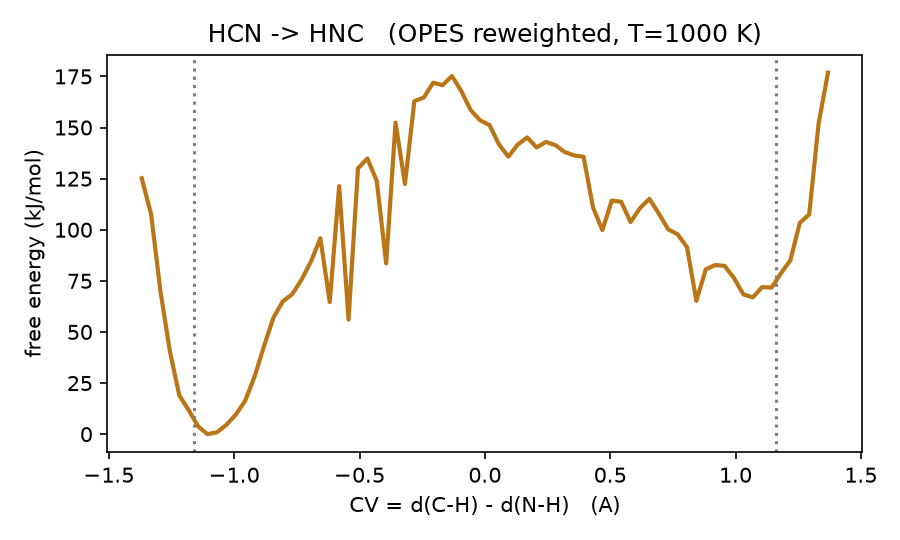

GATE D OK -> fes_hcn.png


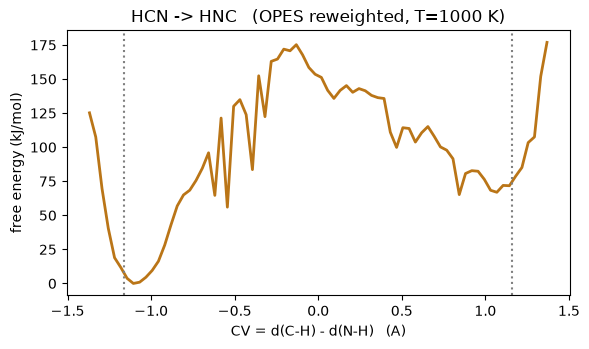

In [10]:
import numpy as np, matplotlib.pyplot as plt
d = np.loadtxt('COLVAR')          # cols: time, cv, dch, dnh, opes.bias
cv, bias = d[:,1], d[:,-1]
T  = 1000.0
kT = 8.617333262e-5 * T           # eV  (matches PLUMED's eV bias)

w = np.exp((bias - bias.max())/kT)
counts, edges = np.histogram(cv, bins=80, range=(-1.5, 1.5), weights=w)
ctr = 0.5*(edges[:-1] + edges[1:])
with np.errstate(divide='ignore'):
    F = -kT*np.log(counts/counts.sum())
F[np.isinf(F)] = np.nan; F -= np.nanmin(F)
F *= 96.485                       # eV -> kJ/mol

def basin(lo, hi):
    m = (ctr>lo)&(ctr<hi)&~np.isnan(F); return np.nanmin(F[m]) if m.any() else np.nan
hcn = basin(-1.30, -0.90)         # reactant well  (FIXED from chemistry)
hnc = basin( 0.90,  1.30)         # product well
# barrier = max of F BETWEEN the two (fixed) basins
i_h = np.argmin(np.abs(ctr - (-1.16))); i_n = np.argmin(np.abs(ctr - 1.16))
lo_i, hi_i = sorted((i_h, i_n)); seg = F[lo_i:hi_i+1]
peak = np.nanmax(seg) if np.isfinite(seg).any() else np.nan
fwd, rev, dF = peak - hcn, peak - hnc, hnc - hcn
kcal = 1/4.184
print(f"CV sampled: {cv.min():.2f} -> {cv.max():.2f}")
print(f"forward barrier  (HCN->HNC) ~ {fwd:.0f} kJ/mol ({fwd*kcal:.0f} kcal/mol)   [lit ~125-190]"
      if not np.isnan(fwd) else "forward barrier -> TS region unsampled")
print(f"reverse barrier  (HNC->HCN) ~ {rev:.0f} kJ/mol" if not np.isnan(rev) else "reverse -> unsampled")
print(f"reaction dF      (HCN->HNC) ~ {dF:.0f} kJ/mol   [lit: HNC ~60 kJ/mol above HCN]"
      if not np.isnan(dF) else "dF -> product unsampled")

plt.figure(figsize=(6,3.6)); plt.plot(ctr, F, lw=2, color='#BA7517')
plt.axvline(-1.16, ls=':', c='gray'); plt.axvline(1.16, ls=':', c='gray')
plt.xlabel('CV = d(C-H) - d(N-H)   (A)'); plt.ylabel('free energy (kJ/mol)')
plt.title('HCN -> HNC   (OPES reweighted, T=1000 K)')
plt.tight_layout(); plt.savefig('fes_hcn.png', dpi=150);
plt.savefig('fes_hcn.png', dpi=150)
from IPython.display import Image, display
display(Image('fes_hcn.png'))
print('GATE D OK -> fes_hcn.png')


In [ ]:
# MOVIE !!

In [32]:
%%writefile render_movie.py
# steered HCN->HNC trajectory on the trained MLIP, rendered to GIF.
# A MOVINGRESTRAINT drags the CV from -1.16 (HCN) to +1.16 (HNC), so the H
# migration plays out cleanly every run (this is for a *movie*, not sampling).
import os, glob, numpy as np
if 'PLUMED_KERNEL' not in os.environ:
    import sys
    _envp = os.path.dirname(os.path.dirname(sys.executable))
    ker = glob.glob(os.path.join(_envp, 'lib', 'libplumedKernel.so'))
    if ker: os.environ['PLUMED_KERNEL'] = ker[0]

from ase import Atoms, units
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.calculators.plumed import Plumed
from ase.io import write
from deepmd.calculator import DP
from PIL import Image

model = sorted(glob.glob("frozen_model.*"))[0]; print("model:", model)
T, NSTEPS, EVERY = 600.0, 40000, 100           # 600 K, 10 ps
dCN = 1.16
atoms = Atoms("CNH", positions=[[0,0,0],[dCN,0,0],[-1.066,0,0]], cell=[20,20,20], pbc=True)
atoms.center()

ps, ts = 1000*units.fs, 0.25*units.fs
pin = [
    f"UNITS LENGTH=A TIME={1/ps} ENERGY={units.mol/units.kJ}",
    "dch: DISTANCE ATOMS=1,3", "dnh: DISTANCE ATOMS=2,3",
    "cv: COMBINE ARG=dch,dnh COEFFICIENTS=1,-1 PERIODIC=NO",
    "uwc: UPPER_WALLS ARG=dch AT=2.6 KAPPA=20.0",
    "uwn: UPPER_WALLS ARG=dnh AT=2.6 KAPPA=20.0",
    f"mr: MOVINGRESTRAINT ARG=cv STEP0=0 AT0=-1.16 KAPPA0=80 "
    f"STEP1={NSTEPS} AT1=1.16 KAPPA1=80",
    "PRINT ARG=cv STRIDE=100 FILE=COLVAR_movie",
]
atoms.calc = Plumed(calc=DP(model=model), input=pin, timestep=ts, atoms=atoms, kT=units.kB*T)
MaxwellBoltzmannDistribution(atoms, temperature_K=T)
dyn = Langevin(atoms, ts, temperature_K=T, friction=0.1)

frames = []
def grab():
    a = atoms.copy()
    a.positions -= a.positions[:2].mean(0)        # recenter on C-N midpoint (no jump)
    a.positions += np.array([10, 10, 10])
    frames.append(a)
dyn.attach(grab, interval=EVERY)
dyn.run(NSTEPS)
print(f"collected {len(frames)} frames")

os.makedirs("movie_frames", exist_ok=True)
paths = []
for i, at in enumerate(frames):
    fn = f"movie_frames/f{i:04d}.png"
    write(fn, at, rotation="10x,0y,0z", show_unit_cell=0,
          scale=80,                          # <-- was 120; zoom out
          maxwidth=300)                      # cap image width, keeps it tidy
    paths.append(fn)
ims = [Image.open(p).convert("RGB") for p in paths]
ims[0].save("hcn_movie.gif", save_all=True, append_images=ims[1:], duration=60, loop=0)
print("wrote hcn_movie.gif with", len(ims), "frames")

Overwriting render_movie.py


In [33]:
import os, glob
print("gif exists:", os.path.exists("hcn_movie.gif"))
print("frames rendered:", len(glob.glob("movie_frames/*.png")))
print("COLVAR_movie exists:", os.path.exists("COLVAR_movie"))

gif exists: True
frames rendered: 1001
COLVAR_movie exists: True


In [34]:
!{PY} render_movie.py
from IPython.display import Image as IPImage, display
display(IPImage("hcn_movie.gif"))

model: frozen_model.pb
To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.
I0000 00:00:1783149306.767682    9193 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/hp/miniforge3/envs/ch4mlip/lib/libplumedKernel.so" +++
PLUMED: PLUMED is starting
PLUMED: Version: 2.9.3 (git: Unknown) compiled on Jun 23 2026 at 09:44:50
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /home/hp/miniforge3/envs/ch4mlip/lib/plumed
PLUMED: For installed feature, see /h

# Stage F · Reference **NEB** — independent 0 K barrier (emulates the RAL paper)
NEB is a *static* minimum-energy-path finder (not sampling): it relaxes a chain of images
between the **fixed** HCN and HNC endpoints to the saddle, giving a **0 K barrier** that is
independent of OPES. Run on the trained MLIP (ASE `aseneb`, paper params: 7 images, spring
k=0.1 eV/Å, FIRE, converge 0.1 eV/Å). Three numbers should now agree: **literature ≈ 125–190
kJ/mol**, this **NEB**, and your **OPES** barrier. If they do, the pipeline is validated.

_(To get a true DFT reference instead of the MLIP path, swap `DP(model=model)` for a Psi4 ASE
calculator — slower, but exact. The MLIP-NEB-vs-literature check already tells you if the model
learned the PES.)_

In [24]:
%%writefile neb_reference.py
import glob, numpy as np
from ase import Atoms
from ase.optimize import FIRE
try:
    from ase.mep import NEB           # newer ASE
except Exception:
    from ase.neb import NEB           # older ASE
from deepmd.calculator import DP

model = sorted(glob.glob("frozen_model.*"))[0]; print("model:", model)
dCN = 1.16
def dp(): return DP(model=model)

# endpoints (C, N, H) -- same atom order as training
hcn = Atoms("CNH", positions=[[0,0,0],[dCN,0,0],[-1.066,0,0]], cell=[20,20,20], pbc=True); hcn.center()
hnc = Atoms("CNH", positions=[[0,0,0],[dCN,0,0],[dCN+0.994,0,0]], cell=[20,20,20], pbc=True); hnc.center()

# relax both wells on the MLIP first (NEB needs minima as endpoints)
for a in (hcn, hnc):
    a.calc = dp(); FIRE(a, logfile=None).run(fmax=0.05, steps=300)

n_img = 5                                  # 5 intermediate -> 7 images total (paper)
images = [hcn] + [hcn.copy() for _ in range(n_img)] + [hnc]
for im in images: im.calc = dp()
neb = NEB(images, k=0.1, climb=True, method='improvedtangent')      # paper: no climbing image
neb.interpolate(method="idpp")             # IDPP avoids H passing through the C-N bond
FIRE(neb, logfile=None).run(fmax=0.05, steps=1500)

E = np.array([im.get_potential_energy() for im in images])
E = (E - E[0]) * 96.485                     # eV -> kJ/mol, reactant = 0
np.savetxt("neb_profile.txt", E)
print("band (kJ/mol):", np.round(E, 1))
print(f"NEB forward barrier (HCN->HNC, 0 K) ~ {E.max():.0f} kJ/mol ({E.max()/4.184:.0f} kcal/mol)")
print(f"NEB reaction energy (HCN->HNC)      ~ {E[-1]:.0f} kJ/mol   [lit ~60]")
print("literature forward barrier ~ 125-190 kJ/mol (level-dependent)")
import numpy as np
for i, im in enumerate(images):
    p = im.get_positions()
    dmin = min(np.linalg.norm(p[a]-p[b]) for a in range(3) for b in range(a+1,3))
    print(f"image {i}: E={ (im.get_potential_energy()-images[0].get_potential_energy())*96.485:.0f} kJ/mol, min dist={dmin:.2f} A")

Overwriting neb_reference.py


model: frozen_model.pb
To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.
I0000 00:00:1783110568.781147    3464 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.
You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.
You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.
You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.
You can use the environment variable DP_

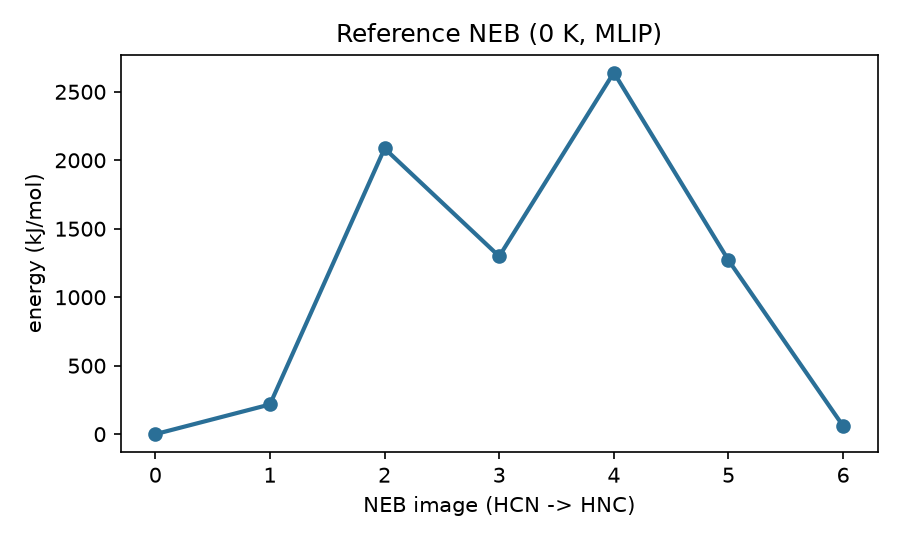

GATE F OK -> neb_hcn.png


In [25]:
!{PY} neb_reference.py
import numpy as np, matplotlib.pyplot as plt, os
if os.path.exists("neb_profile.txt"):
    E = np.loadtxt("neb_profile.txt")
    plt.figure(figsize=(6,3.6)); plt.plot(range(len(E)), E, 'o-', lw=2, color='#2a6f97')
    plt.xlabel('NEB image (HCN -> HNC)'); plt.ylabel('energy (kJ/mol)')
    plt.title('Reference NEB (0 K, MLIP)'); plt.tight_layout()
    plt.savefig('neb_hcn.png', dpi=150); 
    from IPython.display import Image, display
    display(Image('neb_hcn.png'))
    print('GATE F OK -> neb_hcn.png')
else:
    print('GATE F FAILED - neb_profile.txt not written')


# Stage E · Active Learning loop (committee → explore → select → relabel)

In [ ]:
%%writefile al.py
"""al.py -- active-learning loop (DP-GEN / QBC style) for HCN <-> HNC.

Committee training, OPES exploration along d(C-H)-d(N-H), committee force-deviation,
band selection + Psi4 (RKS) re-labelling, recursive driver. Shares the SAME frame
store gen_and_label.py created (CH4_ROOT/frames), so the bootstrap seeds iter 0.
"""
import os, sys, glob, json, argparse, subprocess, shutil
import numpy as np

ENV_BIN  = os.path.dirname(sys.executable)
ENV_ROOT = os.path.dirname(ENV_BIN)
DP_BIN   = os.path.join(ENV_BIN, "dp")
if not os.path.exists(DP_BIN): DP_BIN = "dp"
if "PLUMED_KERNEL" not in os.environ:
    ker = glob.glob(os.path.join(ENV_ROOT, "lib", "libplumedKernel.so"))
    if ker: os.environ["PLUMED_KERNEL"] = ker[0]

ROOT   = os.environ.get("CH4_ROOT", os.path.abspath("al_run"))
FRAMES = os.path.join(ROOT, "frames")
DATA   = os.path.join(ROOT, "data")
MODELS = os.path.join(ROOT, "models")
for d in (FRAMES, MODELS): os.makedirs(d, exist_ok=True)

HART2EV = 27.211386245988
BOHR2A  = 0.529177210903
F_CONV  = HART2EV / BOHR2A
SYM   = ["C", "N", "H"]
ATYPE = [0, 1, 2]
BOX   = (np.eye(3) * 20.0).reshape(-1)
dCN   = 1.16

INPUT_TEMPLATE = """{
  "model": {
    "type_map": ["C","N","H"],
    "descriptor": {"type":"se_e2_a","sel":[4,4,4],"rcut_smth":0.5,"rcut":6.0,
                   "neuron":[25,50,100],"axis_neuron":16,"seed":__SEED__},
    "fitting_net": {"type":"ener","neuron":[120,120,120],"resnet_dt":true,"seed":__SEED__}
  },
  "learning_rate": {"type":"exp","start_lr":0.001,"stop_lr":3.5e-08,"decay_steps":2000},
  "loss": {"type":"ener","start_pref_e":0.1,"limit_pref_e":1,
           "start_pref_f":1000,"limit_pref_f":1,"start_pref_v":0,"limit_pref_v":0},
  "training": {
    "training_data": {"systems":["__DATA__"],"batch_size":"auto"},
    "numb_steps":__STEPS__,"seed":__SEED__,"disp_file":"lcurve.out","disp_freq":500,"save_freq":5000
  }
}"""

def hcn_start():
    return np.array([[0.,0.,0.], [dCN,0.,0.], [-1.066,0.,0.]])   # C, N, H(HCN)

# ---------------------------------------------------------------- DFT labelling (RKS)
_PSI4 = None
def _psi4():
    global _PSI4
    if _PSI4 is None:
        import psi4
        psi4.set_memory("2 GB"); psi4.core.set_num_threads(2)
        psi4.set_output_file("psi4_out.log", False)
        psi4.set_options({"reference":"rks", "maxiter":250, "basis":"def2-tzvp", "scf_type":"df"})
        _PSI4 = psi4
    return _PSI4

def label_psi4(pos):
    psi4 = _psi4()
    lines = ["0 1"] + [f"{s} {p[0]:.8f} {p[1]:.8f} {p[2]:.8f}" for s, p in zip(SYM, pos)]
    lines += ["units angstrom", "symmetry c1", "no_com", "no_reorient"]
    mol = psi4.geometry("\n".join(lines))
    try:
        g, wfn = psi4.gradient("b3lyp", molecule=mol, return_wfn=True)
    except Exception as e:
        print("  SCF/gradient failed:", e); return None
    return mol.geometry().to_array()*BOHR2A, wfn.energy()*HART2EV, -np.array(g)*F_CONV

# ----------------------------------------------- resumable frame store
def _fpath(i): return os.path.join(FRAMES, f"frame_{i:05d}.npz")
def _save(path, **a):
    tmp = path + ".tmp"
    with open(tmp, "wb") as fh: np.savez(fh, **a)
    os.replace(tmp, path)
def save_frame(i, c, e, f): _save(_fpath(i), coord=c, energy=np.array([e]), force=f, ok=np.array([1]))
def save_failed(i):         _save(_fpath(i), failed=np.array([1]))
def done_indices():
    return {int(os.path.basename(f)[6:11]) for f in glob.glob(os.path.join(FRAMES, "frame_*.npz"))}
def next_index():
    d = done_indices(); return (max(d) + 1) if d else 0

def assemble_dataset():
    C, E, F = [], [], []
    for fp in sorted(glob.glob(os.path.join(FRAMES, "frame_*.npz"))):
        z = np.load(fp)
        if "ok" not in z.files: continue
        C.append(z["coord"].reshape(-1)); E.append(float(z["energy"][0])); F.append(z["force"].reshape(-1))
    if not E: raise RuntimeError("no good frames in " + FRAMES + " (run Stage A first)")
    s = os.path.join(DATA, "set.000"); os.makedirs(s, exist_ok=True)
    np.save(os.path.join(s,"coord.npy"),  np.array(C))
    np.save(os.path.join(s,"energy.npy"), np.array(E))
    np.save(os.path.join(s,"force.npy"),  np.array(F))
    np.save(os.path.join(s,"box.npy"), np.tile(BOX, (len(E),1)))
    open(os.path.join(DATA,"type.raw"),"w").write("\n".join(map(str, ATYPE)) + "\n")
    open(os.path.join(DATA,"type_map.raw"),"w").write("C\nN\nH\n")
    open(os.path.join(DATA,"nopbc"),"w").write("")
    return len(E)

# ---------------------------------------------------------------- committee
def train_committee(n_models=4, steps=20000):
    out = []
    for s in range(n_models):
        ex = glob.glob(os.path.join(MODELS, f"model_{s}.*"))
        if ex: print(f"[committee] model_{s} exists, skip"); out.append(ex[0]); continue
        wd = os.path.join(MODELS, f"train_{s}"); os.makedirs(wd, exist_ok=True)
        inp = (INPUT_TEMPLATE.replace("__SEED__", str(s+1))
               .replace("__DATA__", os.path.abspath(DATA)).replace("__STEPS__", str(steps)))
        json.loads(inp); open(os.path.join(wd, "input.json"), "w").write(inp)
        print(f"[committee] training model_{s} ...")
        subprocess.run([DP_BIN, "train", "input.json"], cwd=wd, check=True)
        subprocess.run([DP_BIN, "freeze"], cwd=wd, check=True)
        frozen = (glob.glob(os.path.join(wd,"frozen_model.pb")) +
                  glob.glob(os.path.join(wd,"frozen_model.pth")))[0]
        dst = os.path.join(MODELS, f"model_{s}{os.path.splitext(frozen)[1]}")
        shutil.copy(frozen, dst); out.append(dst)
    print("[committee] ready:", out); return out

def load_committee(n_models=4):
    from deepmd.infer import DeepPot
    paths = sorted(glob.glob(os.path.join(MODELS,"model_*.pb")) +
                   glob.glob(os.path.join(MODELS,"model_*.pth")))
    return [DeepPot(p) for p in paths[:n_models]]

def force_deviation(models, coord):
    fs = []
    for m in models:
        _, f, _ = m.eval(coord.reshape(1, -1), None, ATYPE)
        fs.append(np.array(f).reshape(-1, 3))
    fs = np.array(fs); fbar = fs.mean(0)
    per_atom = np.sqrt(((fs - fbar) ** 2).sum(-1).mean(0))
    return float(per_atom.max()), float(per_atom.mean())

# ---------------------------------------------------------------- explore (OPES on the CV)
def explore(out_xyz, bias="opes", temperature=1000.0, nsteps=20000, dump_every=20):
    from ase import Atoms, units
    from ase.md.langevin import Langevin
    from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
    from ase.io import write
    from deepmd.calculator import DP
    for f in glob.glob("KERNELS_al*"): os.remove(f)
    model = sorted(glob.glob(os.path.join(MODELS, "model_0.*")))[0]
    atoms = Atoms("CNH", positions=hcn_start(), cell=[20,20,20], pbc=True); atoms.center()
    ps, ts = 1000 * units.fs, 0.25 * units.fs
    if bias == "opes":
        from ase.calculators.plumed import Plumed
        pin = [
            f"UNITS LENGTH=A TIME={1/ps} ENERGY={units.mol/units.kJ}",
            "dch: DISTANCE ATOMS=1,3", "dnh: DISTANCE ATOMS=2,3",
            "cv: COMBINE ARG=dch,dnh COEFFICIENTS=1,-1 PERIODIC=NO",
            "uwc: UPPER_WALLS ARG=dch AT=2.6 KAPPA=20.0",
            "uwn: UPPER_WALLS ARG=dnh AT=2.6 KAPPA=20.0",
            "lwcv: LOWER_WALLS ARG=cv AT=-1.5 KAPPA=20.0",
            "uwcv: UPPER_WALLS ARG=cv AT=1.5 KAPPA=20.0",
            "opes: OPES_METAD ARG=cv PACE=500 BARRIER=2.0 SIGMA=0.05 TEMP=1000 FILE=KERNELS_al",
            "PRINT ARG=cv,dch,dnh,opes.bias STRIDE=20 FILE=COLVAR",
            "FLUSH STRIDE=200",
        ]
        atoms.calc = Plumed(calc=DP(model=model), input=pin, timestep=ts, atoms=atoms,
                            kT=units.kB*temperature)
    else:
        atoms.calc = DP(model=model)
    MaxwellBoltzmannDistribution(atoms, temperature_K=temperature)
    dyn = Langevin(atoms, ts, temperature_K=temperature, friction=0.1)
    frames = []
    dyn.attach(lambda: frames.append(atoms.copy()), interval=dump_every)
    dyn.run(nsteps)
    write(out_xyz, frames)
    print(f"[explore] {bias} T={temperature}K -> {len(frames)} frames")
    return out_xyz

# ---------------------------------------------------------------- deviation + select
def cv_coord(pos):
    return float(np.linalg.norm(pos[2]-pos[0]) - np.linalg.norm(pos[2]-pos[1]))  # d(C-H)-d(N-H)

def model_devi(traj, out):
    from ase.io import read
    frames = read(traj, index=":"); models = load_committee()
    rows = [(i, *force_deviation(models, at.get_positions())) for i, at in enumerate(frames)]
    np.savetxt(out, np.array(rows), fmt=["%d","%.6f","%.6f"], header="idx sigma_max sigma_mean")
    a = np.array(rows)
    print(f"[devi] {len(rows)} frames | sigma_max {a[:,1].min():.3f}..{a[:,1].max():.3f} eV/A")
    return out

def select_label(traj, devi, lo=0.12, hi=0.45, max_label=20, cv_gap=0.05):
    from ase.io import read
    frames = read(traj, index=":")
    d = np.loadtxt(devi); d = d[None, :] if d.ndim == 1 else d
    smax = d[:, 1]; cand = np.where((smax > lo) & (smax < hi))[0]
    print(f"[select] candidates={len(cand)} failed(>{hi})={int((smax>=hi).sum())} "
          f"accurate(<{lo})={int((smax<=lo).sum())}")
    cand = cand[np.argsort(-smax[cand])]
    picked, cvs = [], []
    for idx in cand:
        cvv = cv_coord(frames[idx].get_positions())
        if all(abs(cvv - p) > cv_gap for p in cvs):
            picked.append(idx); cvs.append(cvv)
        if len(picked) >= max_label: break
    base, nlab = next_index(), 0
    for k, idx in enumerate(picked):
        r = label_psi4(frames[idx].get_positions())
        if r is None: save_failed(base + k); continue
        save_frame(base + k, *r); nlab += 1
        if k % 5 == 0: print(f"  labelled {k+1}/{len(picked)}  E={r[1]:.3f} eV")
    print(f"[select] added {nlab} new DFT frames")
    return len(picked), nlab

# ---------------------------------------------------------------- driver
def run_al(max_iter=3, converge_frac=0.02, bias="opes", temp=1000.0, nsteps=20000,
           lo=0.12, hi=0.45, max_label=20, committee_steps=20000):
    state_f = os.path.join(ROOT, "al_state.json")
    state = json.load(open(state_f)) if os.path.exists(state_f) else {"iter": 0, "history": []}
    while state["iter"] < max_iter:
        it = state["iter"]; wd = os.path.join(ROOT, f"iter_{it:02d}"); os.makedirs(wd, exist_ok=True)
        print(f"\n========== AL iteration {it} ==========")
        n = assemble_dataset(); print(f"[iter {it}] dataset = {n} frames")
        train_committee(steps=committee_steps)
        traj = os.path.join(wd, "explore.xyz")
        if not os.path.exists(traj): explore(traj, bias=bias, temperature=temp, nsteps=nsteps)
        devi = os.path.join(wd, "model_devi.out")
        if not os.path.exists(devi): model_devi(traj, devi)
        npick, nlab = select_label(traj, devi, lo=lo, hi=hi, max_label=max_label)
        ntot = len(np.atleast_2d(np.loadtxt(devi))); frac = npick / max(ntot, 1)
        print(f"[iter {it}] candidate fraction = {frac:.3f}, labelled {nlab}")
        state["history"].append({"iter": it, "cand_frac": frac, "labelled": nlab})
        state["iter"] += 1; json.dump(state, open(state_f, "w"), indent=1)
        if nlab > 0:
            for f in os.listdir(MODELS):
                p = os.path.join(MODELS, f)
                if f.startswith(("model_", "train_")):
                    os.remove(p) if os.path.isfile(p) else shutil.rmtree(p)
        if frac < converge_frac and nlab == 0:
            print(f"\nCONVERGED: candidate fraction {frac:.3f} < {converge_frac}"); break
    print("\nAL history:", json.dumps(state["history"], indent=1))
    return state

if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--max_iter", type=int, default=3)
    ap.add_argument("--bias", default="opes", choices=["opes", "none"])
    ap.add_argument("--temp", type=float, default=1000.0)
    ap.add_argument("--nsteps", type=int, default=20000)
    ap.add_argument("--lo", type=float, default=0.12)
    ap.add_argument("--hi", type=float, default=0.45)
    ap.add_argument("--max_label", type=int, default=20)
    ap.add_argument("--committee_steps", type=int, default=20000)
    ap.add_argument("--converge_frac", type=float, default=0.02)
    a = ap.parse_args()
    run_al(max_iter=a.max_iter, converge_frac=a.converge_frac, bias=a.bias, temp=a.temp,
           nsteps=a.nsteps, lo=a.lo, hi=a.hi, max_label=a.max_label, committee_steps=a.committee_steps)


In [ ]:
# 3 AL iterations, OPES exploration at 1000 K, label up to 20 configs/iter.
!{PY} al.py --max_iter 3 --bias opes --temp 1000 --max_label 20 --committee_steps 15000


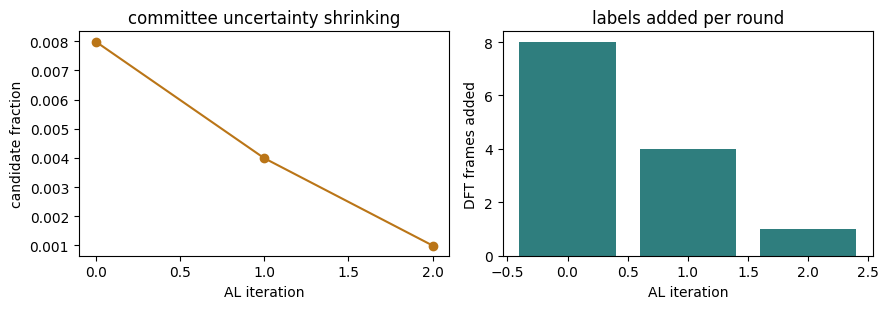

history: [{'iter': 0, 'cand_frac': 0.007992007992007992, 'labelled': 8}, {'iter': 1, 'cand_frac': 0.003996003996003996, 'labelled': 4}, {'iter': 2, 'cand_frac': 0.000999000999000999, 'labelled': 1}]
After convergence: re-run Stage B/C/D -- the committee patched the holes,
so the FES should be cleaner (no spurious low-c dip).


In [ ]:
import json, os, matplotlib.pyplot as plt
state = json.load(open(os.path.join(os.environ['CH4_ROOT'], 'al_state.json')))
h = state['history']; its=[x['iter'] for x in h]
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(its, [x['cand_frac'] for x in h], 'o-', color='#BA7517')
ax[0].set_xlabel('AL iteration'); ax[0].set_ylabel('candidate fraction')
ax[0].set_title('committee uncertainty shrinking')
ax[1].bar(its, [x['labelled'] for x in h], color='#2F7E7E')
ax[1].set_xlabel('AL iteration'); ax[1].set_ylabel('DFT frames added')
ax[1].set_title('labels added per round')
plt.tight_layout(); plt.savefig('al_history.png', dpi=150); plt.show()
print('history:', h)
print('After convergence: re-run Stage B/C/D -- the committee patched the holes,')
print('so the FES should be cleaner (no spurious low-c dip).')

In [ ]:
import os, glob, shutil
DEST = os.path.join(os.environ['CH4_ROOT'], 'final_outputs')
os.makedirs(DEST, exist_ok=True)
for pat in ['frozen_model.*', 'fes_hcn.png', 'neb_hcn.png', 'neb_profile.txt', 'lcurve.out', 'COLVAR']:
    for f in glob.glob(pat):
        shutil.copy(f, DEST)
print('saved final outputs to', DEST)

## Reading the result & validation checklist

This is a **pipeline calibration**, so it has falsifiable pass/fail checks:

1. **Stage A** prints the dataset energy spread — it should be **>~100 kJ/mol** across the
   migration path. (If it were ~0, labeling would be broken; RKS on this closed-shell reaction
   should give a clean, large spread — unlike the CH4 homolysis, which collapsed.)
2. **Stage D (OPES FES)** should show a **double well** — HCN near CV=-1.16, HNC near CV=+1.16 —
   with the forward barrier in the **~125-190 kJ/mol** literature range and HNC **~60 kJ/mol**
   above HCN.
3. **Stage F (NEB)** gives an independent **0 K** barrier that should land in the same
   ~125-190 kJ/mol window and a reaction energy ~60 kJ/mol.

If the OPES barrier, the NEB barrier, and the literature value all agree, **every part of your
pipeline is validated** (labeling, training, enhanced sampling, reweighting, NEB) — and you can
return to the CH4/Cu-In work knowing the machinery is sound and the only remaining challenge
there is the spin/surface physics.

**Notes**
* **Closed-shell by design:** RKS is correct here (no radicals), which is exactly why this is a
  clean test — it sidesteps the broken-symmetry/multireference problem that made CH4 homolysis
  unreliable at the labeling level.
* **Temperature:** sampling runs at **1000 K** because the barrier is high; the OPES free-energy
  barrier (finite-T) and the NEB electronic barrier (0 K) differ slightly by entropy but should
  be the same order.
* **NEB on the MLIP** checks whether the model learned the PES. For a true DFT reference, swap the
  DP calculator for a Psi4 ASE calculator in neb_reference.py (slower).